# Versuchsaufbau (Aufgabe1)
Der Versuchsaufbau von Aufgabe 1 war einne aukustische Bank, bei der zwei Schieber mit einem Sender und Empfänger verschoben werden können. Der Sender ist mit einem Signalerzeuger verbunden, während der Empfänger mit dem Oszilloskop und dem Spannungsmesser verbunden war.
Für die verschiedenen Teilaufgaben in der ersten Aufgabe wurde verschieden vorgegangen.
b) Hierfür wurde für einen festen Abstand, für verschiedene Frequenzen die Amplitude über das Messgerät gemessen um herauszufinden wann die Amplitude der Frequenz am größten beim Empfänger ist. Die ermittelte Resonanzfrequenz wurde in allen anderen Versuchen dann benutzt.
c) Für c) wurde die Amplitude für eine feste Frequenz, der Empfänger immer weiter von dem Sender weggeschoben. Es wird eine $1/r$ abhängigkeit erwartet, wegen des kugelwellen Charakters der Schallwelle.
d) Es wurde für bestimmte Lissajous-Figuren, die eine gewisse Phasendifferenz beschreiben der Abstand zwischen Sender und Empfänger gemessen. Dabei war die Frequenz fest und nur der Abstand wurde geändert.
e) FÜr die letzte Teilaufgabe in 1 wurde für eine feste Frequenz für verschiedene Abstände die Zeit gemessen, die das Signal vom Sender zum Empfänger braucht. Dabei wird die Schallgeschwindigkeit als geradlinige gleichmäßige Bewegung angenommen.

## Teilaufgabe b

U₀         = 180.72 mV
f₀         = 41.11471 kHz
Γ links    = 1.27101 kHz
Γ rechts   = 0.59838 kHz
Offset     = 17.29 mV


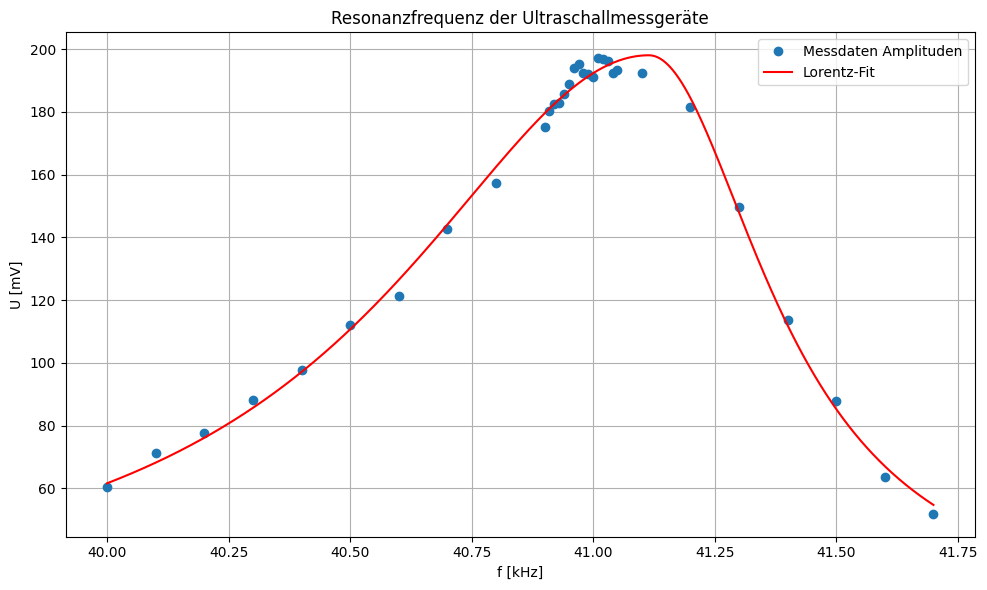

In [65]:
# | fig-cap: Resonanzfrequenz der Ultraschallmessgeräte
# | label: fig-resonanzfreq
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

df = pd.read_csv("./daten/Aufgabe1b.csv")
df.columns = ["f [kHz]", "U [mV]"]
f_kHz = df["f [kHz]"].values
U_mV = df["U [mV]"].values

# Asymmetrische Lorentz-Funktion
def asym_lorentz(f, U0, f0, gamma_L, gamma_R, offset):
    gamma = np.where(f < f0, gamma_L, gamma_R)
    return U0 * (0.5 * gamma)**2 / ((f - f0)**2 + (0.5 * gamma)**2) + offset

# Schätzwerte
U0_guess = U_mV.max() - U_mV.min()
f0_guess = f_kHz[np.argmax(U_mV)]
gamma_L_guess = 0.05
gamma_R_guess = 0.1
offset_guess = U_mV.min()

popt, _ = curve_fit(asym_lorentz, f_kHz, U_mV,
                    p0=[U0_guess, f0_guess, gamma_L_guess, gamma_R_guess, offset_guess])

U0_fit, f0_fit, gamma_L_fit, gamma_R_fit, offset_fit = popt

# Fit-Kurve
f_fit = np.linspace(f_kHz.min(), f_kHz.max(), 1000)
U_fit = asym_lorentz(f_fit, *popt)

# Parameter anzeigen
print(f"U₀         = {U0_fit:.2f} mV")
print(f"f₀         = {f0_fit:.5f} kHz")
print(f"Γ links    = {gamma_L_fit:.5f} kHz")
print(f"Γ rechts   = {gamma_R_fit:.5f} kHz")
print(f"Offset     = {offset_fit:.2f} mV")

plt.figure(figsize=(10, 6))
plt.plot(df['f [kHz]'], df['U [mV]'], 'o', label='Messdaten Amplituden')
plt.plot(f_fit, U_fit, 'r-', label='Lorentz-Fit')
plt.xlabel('f [kHz]')
plt.ylabel('U [mV]')
plt.title("Resonanzfrequenz der Ultraschallmessgeräte")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



## Teilaufgabe c


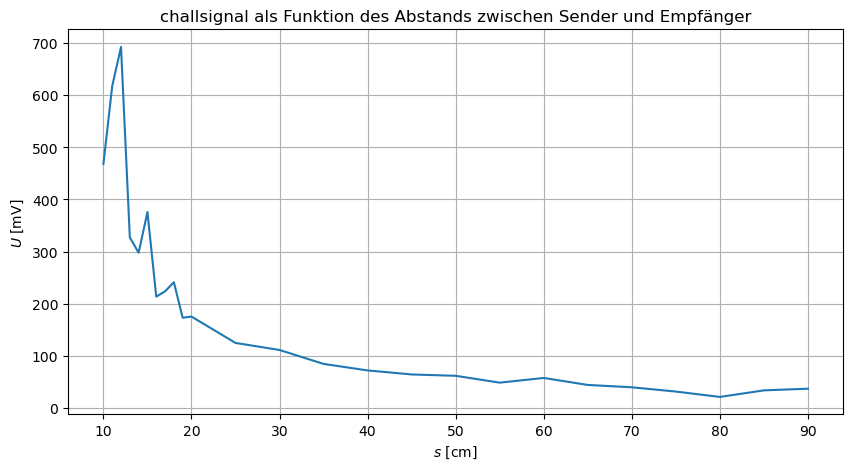

In [ ]:
# | fig-cap: Schallsignal als Funktion des Abstands zwischen Sender und Empfänger
# | label: fig-schallsignal-ueber-abstand
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

daten = pd.read_csv("./daten/Aufgabe1c.csv")

abstand = daten["s [cm]"]
spannung = daten["U [mV]"]

plt.figure(figsize=(10,5))
plt.plot(abstand, spannung)
plt.title("Schallsignal als Funktion des Abstands zwischen Sender und Empfänger")
plt.xlabel("$s$ [cm]")
plt.ylabel("$U$ [mV]")
plt.grid()
plt.show()

## Teilaufgabe d

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from itertools import product
import csv
import statistics

with open('daten/Aufgabe1d.csv', newline='') as f:
    reader = csv.reader(f)
    data = list(reader)

test = []

data.remove(data[0])  # Remove header row
data = data[0:4]
data = sorted(data, key=lambda x: float(x[0]))  # Sort by first column (distance)
print(data)

for i in range(len(data)):
    data[i][0] = 0.01*float(data[i][0])  # Convert first column to float (distance)


for i in range(len(data)):
    for j in range(i+1, len(data)):
       print(j)
       wavelength = 2*(data[j][0] - data[i][0]) / (j-i)
       print(wavelength)
       test.append(wavelength)

statistics.mean(test)
print("Durchschnittliche Wellenlänge:", statistics.mean(test))
print("Geschwindigkeit des Schalls:", statistics.mean(test) * 41.01e3)  # 41.01 kHz is the frequency from Aufgabe1b.csv


[['19', 'True'], ['19.50', 'False'], ['20', 'True'], ['20.40', 'False']]
1
0.010000000000000009
2
0.010000000000000009
3
0.009333333333333324
2
0.010000000000000009
3
0.00899999999999998
3
0.007999999999999952
Durchschnittliche Wellenlänge: 0.00938888888888888
Geschwindigkeit des Schalls: 385.038333333333


## Teilaufgabe e

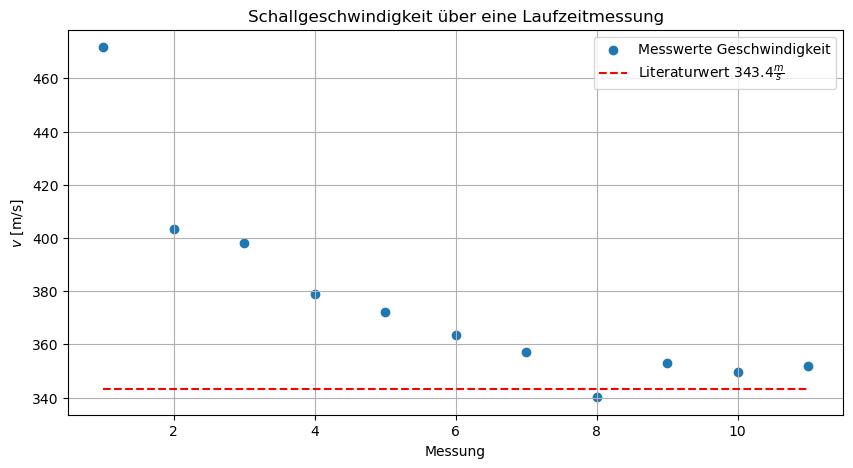

In [24]:
# | fig-cap: Schallgeschwindigkeit über eine Laufzeitmessung
# | label: fig-schallgesch-ueber-laufzeitmess
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

daten = pd.read_csv("./daten/Aufgabe1e.csv")

abstand = daten["s [cm]"] * 10^(-2)
zeit = daten["t [us]"] * 10^(-6)

gesch = daten["v [m/s]"]

plt.figure(figsize=(10,5))
plt.scatter(np.linspace(1, 11, 11), gesch, label="Messwerte Geschwindigkeit")
plt.hlines(343.4, xmin=1, xmax=len(abstand), colors='r', linestyles='--', label="Literaturwert $343.4 \\frac{m}{s}$")
plt.title("Schallgeschwindigkeit über eine Laufzeitmessung")
plt.xlabel("Messung")
plt.ylabel("$v$ [m/s]")
plt.legend()
plt.grid()
plt.show()